# T08 — AR Model (AutoRegressive) — Book: CH05

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 5.

### Book-mandated steps:
1. ADF stationarity test on health_index (level + first difference)
2. ACF and PACF plots to visually determine lag order p
3.  — select p by lowest AIC via SARIMAX(order=(p,0,0))
4. Fit best model → Ljung-Box residual test
5.  — walk-forward validation on representative engine
6. Full-dataset prediction → evaluate with RMSE + NASA score

In [1]:
import sys, os
from pathlib import Path

BASE_DIR = Path("/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting")
ROOT = BASE_DIR.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial

# Book imports — exactly as CH05 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from src.models.classical import (
    load_and_prepare,
    run_stationarity_report, plot_acf_pacf_multi, smooth_series,
    select_best_ar_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_ar, predict_dataset, RUL_CAP,
    simulate_test_from_train, validate_model_rolling,
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
RAW_PATH    = str(ROOT / "data" / "raw" / "train_FD004.txt")
# 16 sensors retained after T04 variance filter (dropped s1, s5, s16, s18, s19)
SENSOR_COLS = [f"s{i}" for i in [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 20, 21]]

## 1. Load data and build health_index

In [3]:
train, test, THRESHOLD = load_and_prepare(PROC_DIR, SENSOR_COLS)

Loaded: train=(61249, 123), test=(41214, 123)
Engines: train=249, test=248
  Degradation-correlation filter (|r| ≥ 0.5):
    Kept    9 sensors: ['s2', 's3', 's4', 's8', 's9', 's11', 's13', 's14', 's17']
    Dropped  7 sensors: ['s6', 's7', 's10', 's12', 's15', 's20', 's21']
  PCA fit on 61249 rows, 9 sensors (|r|≥0.5)
  PC1 explains 76.3% of within-condition variance  (using 9/16 sensors, |r|≥0.5)
  RUL regressor (all data): RUL = -5.19 * hi + 0.00  (R²=-5.189)
  RUL regressor (recent 60%): RUL = -29.69 * hi + 82.68  (R2=0.651)

Failure threshold (q=0.05): 1.4117
Health index range: [-1.531, 6.471]


## 2. Stationarity check — ADF test (CH03 methodology)

Book rule: run ADF at level + first difference. If level p > 0.05 and diff-1 p < 0.05 → d=1.
Here we check a stratified sample across ALL 4 FD subsets, not just 6 engines from FD001.

In [4]:
stationarity_df = run_stationarity_report(train, n_engines=248)
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\nNew MODAL_D = {MODAL_D}")


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9991      0.9931      2.0
2           1.0         0.7229      2.0
3           1.0         0.4577      2.0
4           1.0         0.1697      2.0
5           1.0         0.9941      2.0
6           1.0         0.9811      2.0
7           0.9968      0.0         1.0
8           1.0         0.903       2.0
9           1.0         0.4393      2.0
10          1.0         0.8217      2.0
11          1.0         0.0         1.0
12          1.0         0.6955      2.0
13          1.0         0.0012      1.0
14          1.0         0.992       2.0
15          1.0         0.9545      2.0
16          0.9982      0.9014      2.0
17          1.0         0.9867      2.0
18          1.0         0.9836      2.0
19          0.9954      0.0         1.0
20          1.0         0.7308      2.0
21          1.0         0.6441      2.0
22          1.0      

In [5]:
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print(d_counts.to_string())
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ MODAL_D = {MODAL_D}")

recommended_d
1     59
2    189

→ MODAL_D = 2


## 3. ACF and PACF plots (CH05 methodology)

Book rule: PACF cuts off at lag p → AR order.
Plot on smoothed health_index (smoothing is applied before fitting in production too).

 length: 61249 cycles


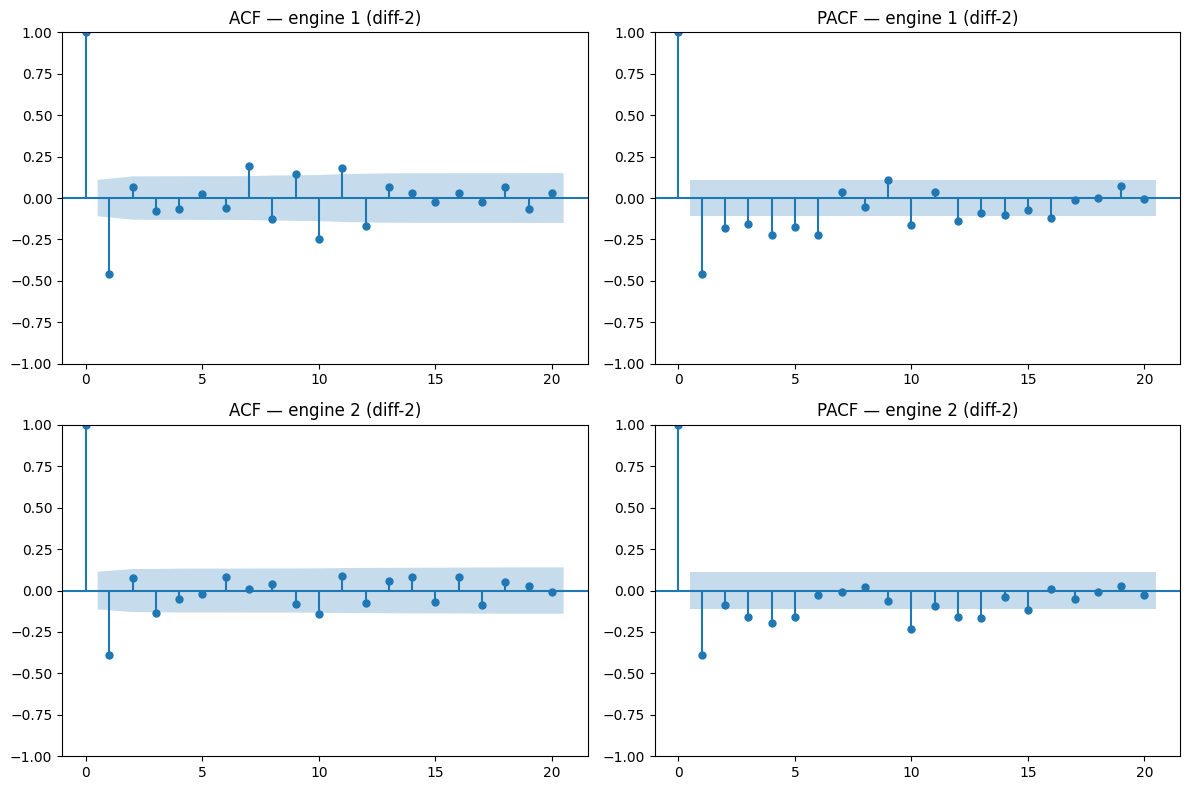

Reading: PACF cuts off at lag p → candidate AR(p)


In [6]:
# Pick one representative engine from FD001 to show ACF/PACF
raw   = train.sort_values("cycle").health_index.values
smth  = smooth_series(raw, window=5)

print(f" length: {len(smth)} cycles")
plot_acf_pacf_multi(train, d=MODAL_D, n_engines=2, lags=20)
print("Reading: PACF cuts off at lag p → candidate AR(p)")

## 4. Optimize AR order by AIC (CH05/CH06 pattern)

Book rule: run optimize function, sort by AIC ascending, pick lowest.

In [7]:
BEST_P = select_best_ar_order(train, d=MODAL_D, n_engines=15)

  engine 1: best p=6  (AIC=-1242.65)
  engine 2: best p=5  (AIC=-1368.39)
  engine 3: best p=5  (AIC=-1400.18)
  engine 4: best p=1  (AIC=-1076.07)
  engine 5: best p=5  (AIC=-790.4)
  engine 6: best p=5  (AIC=-1382.65)
  engine 7: best p=3  (AIC=-1003.45)
  engine 8: best p=2  (AIC=-1070.04)
  engine 9: best p=3  (AIC=-1453.71)
  engine 10: best p=10  (AIC=-1270.73)
  engine 11: best p=2  (AIC=-1403.0)
  engine 12: best p=5  (AIC=-850.02)
  engine 13: best p=4  (AIC=-1110.11)
  engine 14: best p=10  (AIC=-1039.99)
  engine 15: best p=4  (AIC=-866.63)

→ Modal best AR order: p=5  (from 15 engines, freq=[(5, 5), (3, 2), (2, 2), (10, 2), (4, 2)])


## 5. Fit best AR model and check residuals (Ljung-Box)

Book rule (CH06/CH07): always run Ljung-Box after fitting. All p-values > 0.05 = white-noise residuals = adequate model.

In [8]:
rep_eid, rep_smth = _get_representative_engine(train)
# WHY: SARIMAX(p, d, 0) — SARIMAX handles d internally so forecast preserves trend
# Fit on last RECENT_WINDOW cycles (recent degradation is most informative)
from src.models.classical import RECENT_WINDOW
fit_series = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
model_fit = SARIMAX(fit_series, order=(BEST_P, MODAL_D, 0),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(model_fit.resid, model_name=f"AR({BEST_P})")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  541
Model:               SARIMAX(5, 0, 0)   Log Likelihood                1226.212
Date:                Wed, 29 Apr 2026   AIC                          -2440.423
Time:                        16:43:34   BIC                          -2414.663
Sample:                             0   HQIC                         -2430.349
                                - 541                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6322      0.039    -16.029      0.000      -0.709      -0.555
ar.L2         -0.3655      0.045     -8.084      0.000      -0.454      -0.277
ar.L3         -0.2032      0.044     -4.633      0.0

## 6. Rolling forecast on representative engine (CH05 pattern)

Book rule: walk-forward validation — refit at each window step, predict out-of-sample.

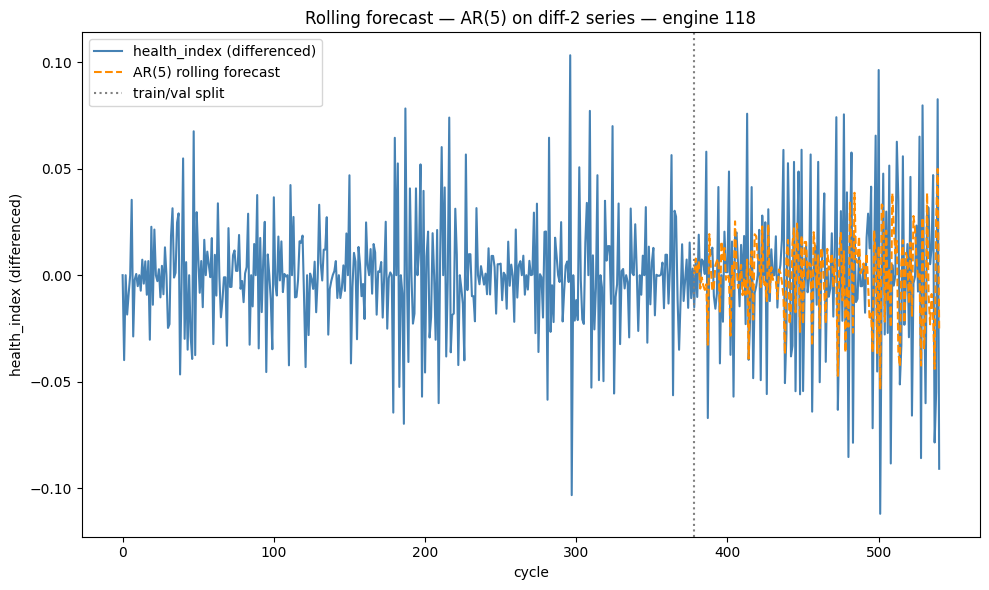

Rolling forecast RMSE (differenced space): 0.0317


In [9]:
TRAIN_LEN = int(len(rep_smth) * 0.7)
WINDOW    = 1

# WHY: SARIMAX(p, d, 0) on original smoothed series (trend-preserving AR)
from src.models.classical import RECENT_WINDOW
fit_series    = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
diff_train_len = min(TRAIN_LEN, len(fit_series) - 1)

pred_ar = rolling_forecast_engine(
    series=fit_series, train_len=diff_train_len,
    order=(BEST_P, MODAL_D, 0),
    window=WINDOW,
)

actual_val = fit_series[diff_train_len: diff_train_len + len(pred_ar)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fit_series, color="steelblue", label="health_index (recent window)")
ax.plot(range(diff_train_len, diff_train_len + len(pred_ar)), pred_ar,
        color="darkorange", ls="--", label=f"AR({BEST_P}) rolling forecast")
ax.axvline(diff_train_len, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"Rolling forecast — AR({BEST_P}) — engine {rep_eid} (recent {RECENT_WINDOW} cycles)")
ax.legend(); plt.tight_layout(); plt.show()

rmse_roll = float(np.sqrt(np.mean((actual_val - pred_ar)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 7. Full test-set evaluation

In [10]:
from src.models.classical import SAFETY_FACTOR
predict_fn = partial(predict_rul_ar, p=BEST_P, pre_diff_d=MODAL_D)
y_true, y_pred = predict_dataset(test, predict_fn, THRESHOLD,
                                 safety_factor=SAFETY_FACTOR, verbose_engines=True)
evaluate(y_true, y_pred, model_name=f"AR({BEST_P})")

    engine    1  true=  22.0  pred=  67.9  err=+45.9
    engine    2  true=  39.0  pred=  62.0  err=+23.0
    engine    3  true= 107.0  pred= 110.3  err=+3.3
    engine    4  true=  75.0  pred= 110.6  err=+35.6
    engine    5  true= 125.0  pred=  78.9  err=-46.1
    engine    6  true=  78.0  pred= 109.7  err=+31.7
    engine    7  true=  94.0  pred=  78.1  err=-15.9
    engine    8  true=  14.0  pred=  46.0  err=+32.0
    engine    9  true=  99.0  pred= 107.1  err=+8.1
    engine   10  true= 125.0  pred= 125.0  err=+0.0
    engine   11  true= 125.0  pred= 107.4  err=-17.6
    engine   12  true=   7.0  pred=  36.0  err=+29.0
    engine   13  true=  71.0  pred=  91.9  err=+20.9
    engine   14  true= 105.0  pred=  87.6  err=-17.4
    engine   15  true=  12.0  pred=  74.0  err=+62.0
    engine   16  true= 125.0  pred= 106.7  err=-18.3
    engine   17  true= 125.0  pred= 101.5  err=-23.5
    engine   18  true= 104.0  pred=  92.1  err=-11.9
    engine   19  true= 125.0  pred= 110.5  err=-1

{'rmse': 34.590641021728516,
 'nasa_score': 162546.34375,
 'nasa_score_mean': 655.4288054435484,
 'r2_score': 0.35231906175613403,
 'bias': 4.684961795806885}

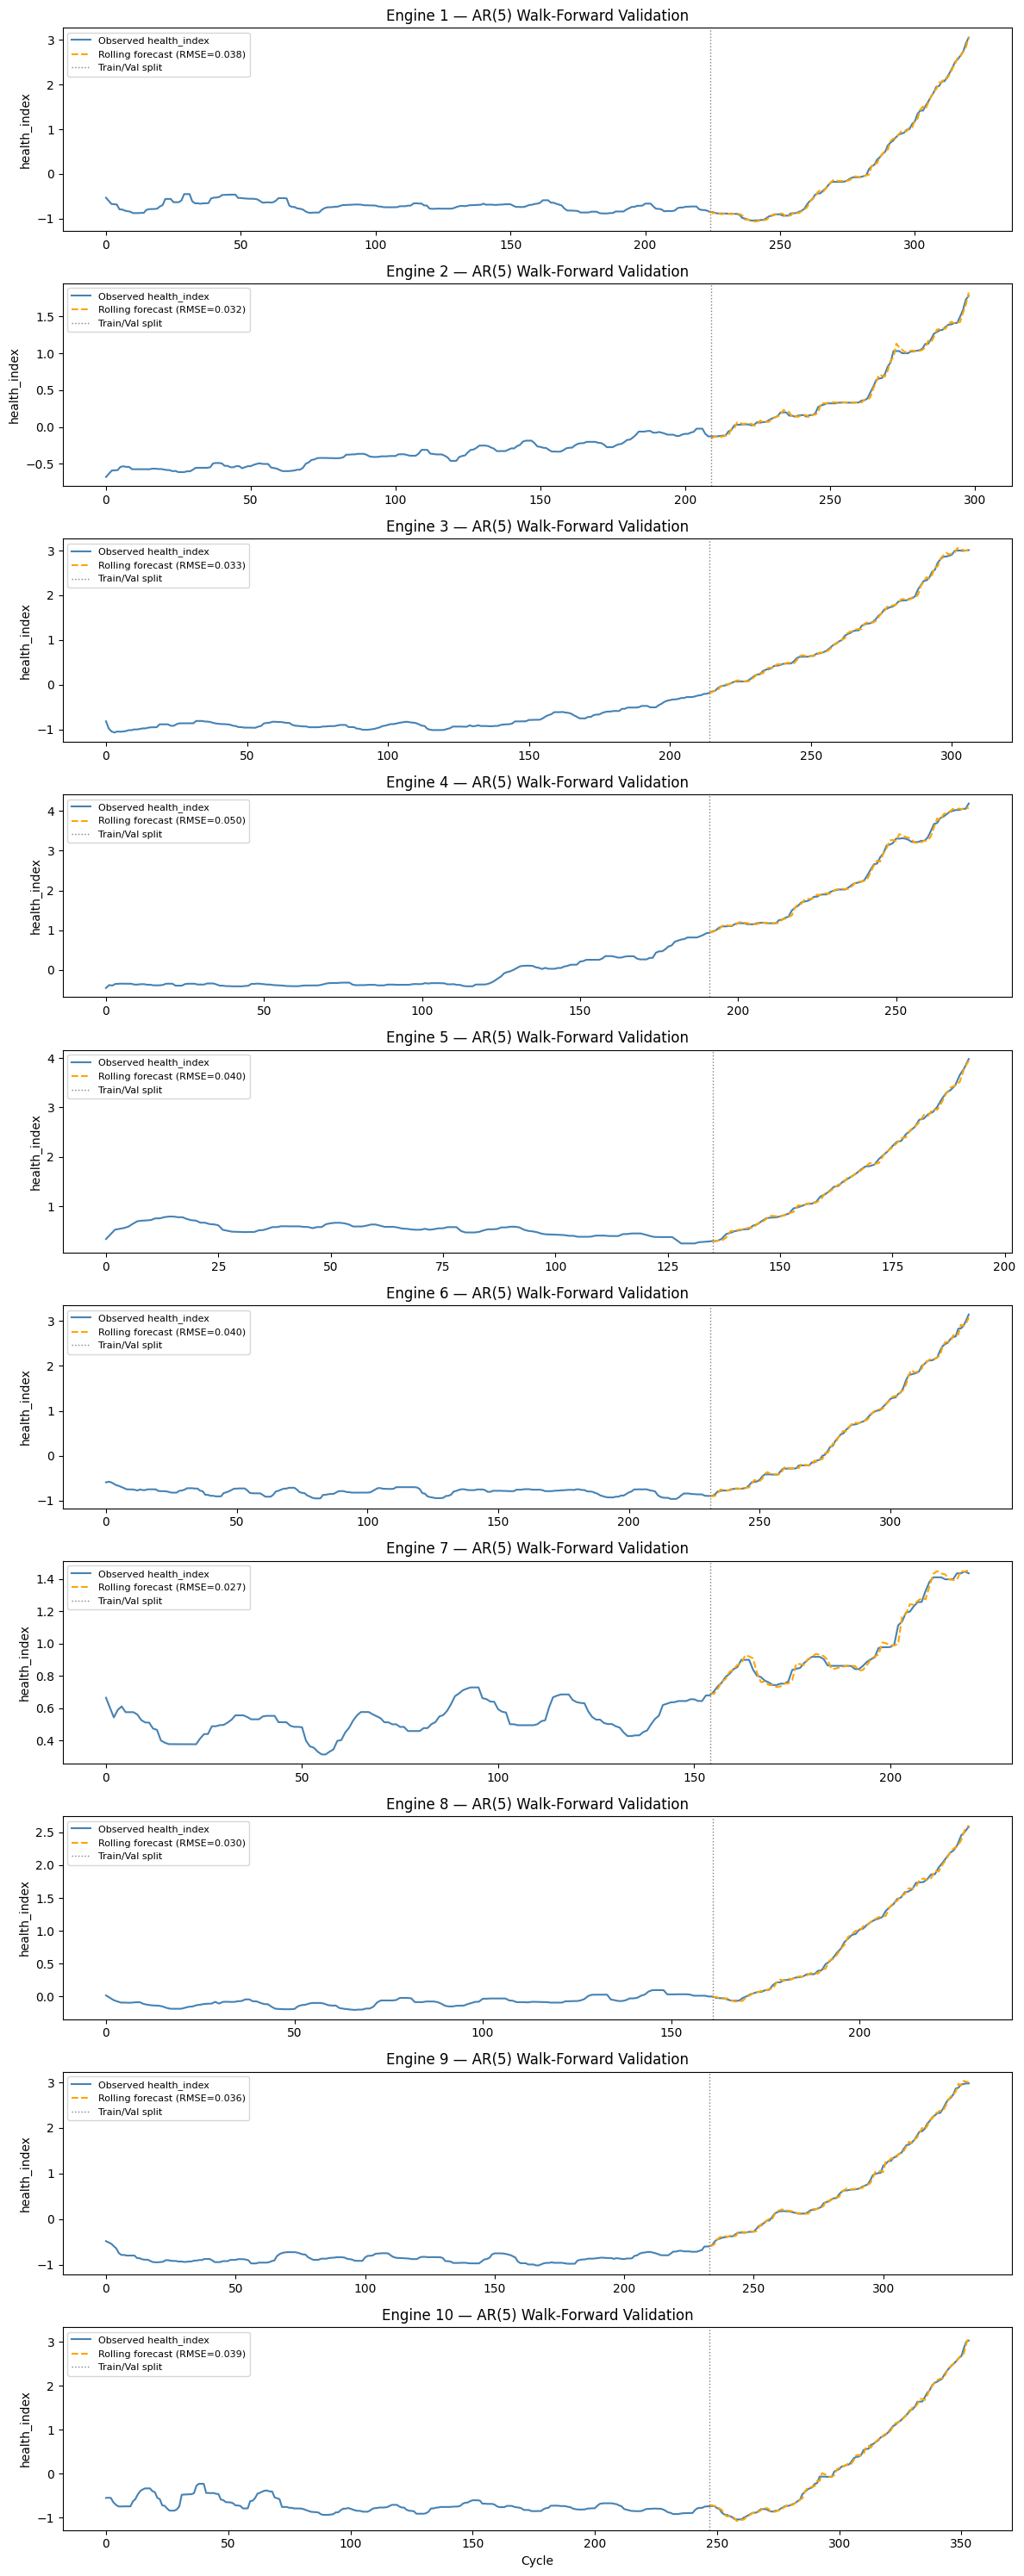


AR(5) Walk-Forward Validation Summary
Engines validated : 10
Mean RMSE         : 0.0366
Std RMSE          : 0.0062
Best engine RMSE  : 0.0271
Worst engine RMSE : 0.0502


In [11]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, 0),   # AR: q=0
    n_engines  = 10,
    model_name = f"AR({BEST_P})"
)